<a href="https://colab.research.google.com/github/VishwanathSR/House-price-pred/blob/main/House%20price%20prediction%20project/house%20price%20prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [112]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [113]:
data = pd.read_csv("https://raw.githubusercontent.com/VishwanathSR/House-price-pred/refs/heads/main/House%20price%20prediction%20project/housing.csv")

In [114]:
data

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND


In [115]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [116]:
data.isnull().sum()

,0
longitude,0
latitude,0
housing_median_age,0
total_rooms,0
total_bedrooms,207
population,0
households,0
median_income,0
median_house_value,0
ocean_proximity,0


In [117]:
data.dropna(inplace=True)
data.isnull().sum()

,0
longitude,0
latitude,0
housing_median_age,0
total_rooms,0
total_bedrooms,0
population,0
households,0
median_income,0
median_house_value,0
ocean_proximity,0


In [118]:
from sklearn.model_selection import train_test_split

In [119]:
x = data.drop(['median_house_value'], axis=1)
y = data['median_house_value']

In [120]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2)

# EDA
* Now before starting with training the model lets inspect the training data. Use join function to join 2 dataframes x_train & y_train together and analyze them

In [121]:
train_data = x_train.join(y_train)
train_data

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity,median_house_value
6918,-118.00,33.96,37.0,2414.0,323.0,878.0,305.0,9.1541,<1H OCEAN,453800.0
12876,-121.36,38.66,22.0,2878.0,599.0,1362.0,541.0,2.7955,INLAND,96500.0
8101,-118.21,33.80,41.0,1251.0,279.0,1053.0,278.0,3.2778,NEAR OCEAN,150800.0
5153,-118.26,33.95,44.0,1513.0,369.0,1088.0,344.0,1.2969,<1H OCEAN,94400.0
19051,-121.81,38.43,30.0,1674.0,297.0,756.0,292.0,3.9286,INLAND,133100.0
...,...,...,...,...,...,...,...,...,...,...
771,-122.11,37.66,29.0,2544.0,643.0,2332.0,603.0,3.2091,NEAR BAY,150000.0
14995,-117.04,32.73,36.0,2084.0,400.0,1097.0,398.0,3.2717,NEAR OCEAN,130700.0
19103,-122.57,38.27,7.0,6508.0,1028.0,2902.0,1010.0,5.3707,<1H OCEAN,250500.0
6062,-117.84,34.00,26.0,797.0,117.0,383.0,114.0,6.8758,<1H OCEAN,253800.0


array([[<Axes: title={'center': 'longitude'}>,
        <Axes: title={'center': 'latitude'}>,
        <Axes: title={'center': 'housing_median_age'}>],
       [<Axes: title={'center': 'total_rooms'}>,
        <Axes: title={'center': 'total_bedrooms'}>,
        <Axes: title={'center': 'population'}>],
       [<Axes: title={'center': 'households'}>,
        <Axes: title={'center': 'median_income'}>,
        <Axes: title={'center': 'median_house_value'}>]], dtype=object)

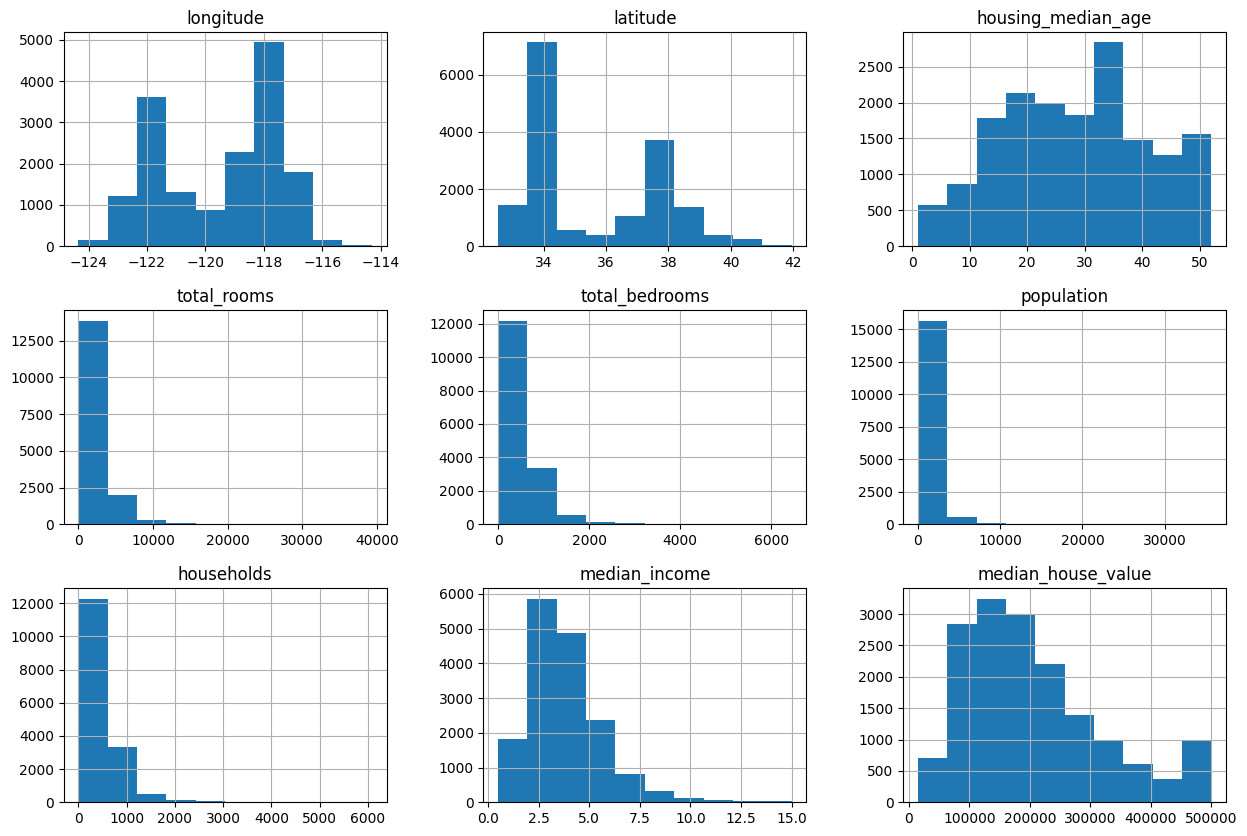

In [122]:
train_data.hist(figsize=(15, 10))

<Axes: >

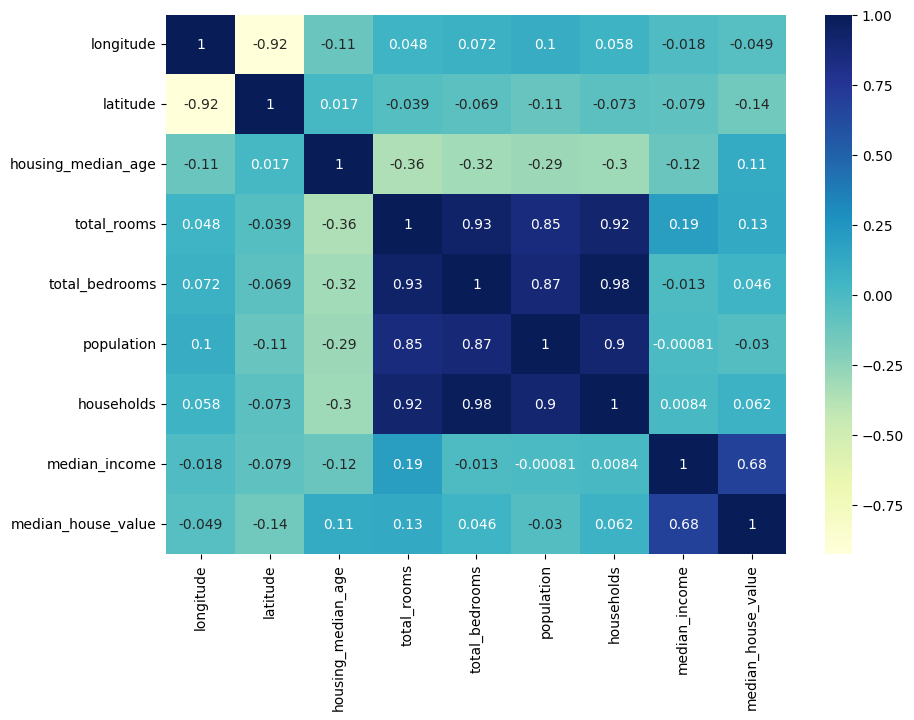

In [123]:
plt.figure(figsize=(10,7))
sns.heatmap(train_data.corr(numeric_only=True), annot=True, cmap="YlGnBu")
# "numeric_onlt=True" is used here to ignore any text based data (e.g. Ocean_proximity) which cannot be plotted.

# Preprocessing (Skewed Curve)
* As we can see in the histogram plot from earlier, there are a few features that are skewed curve, doesnt ressmble gaussian curve. we convert them using log function to get a bell curve that is much more suited to train the model than the raw data.

In [124]:
train_data['total_rooms'] = np.log(train_data['total_rooms'] + 1)
train_data['total_bedrooms'] = np.log(train_data['total_bedrooms'] + 1)
train_data['population'] = np.log(train_data['population'] + 1)
train_data['households'] = np.log(train_data['households'] + 1)

array([[<Axes: title={'center': 'longitude'}>,
        <Axes: title={'center': 'latitude'}>,
        <Axes: title={'center': 'housing_median_age'}>],
       [<Axes: title={'center': 'total_rooms'}>,
        <Axes: title={'center': 'total_bedrooms'}>,
        <Axes: title={'center': 'population'}>],
       [<Axes: title={'center': 'households'}>,
        <Axes: title={'center': 'median_income'}>,
        <Axes: title={'center': 'median_house_value'}>]], dtype=object)

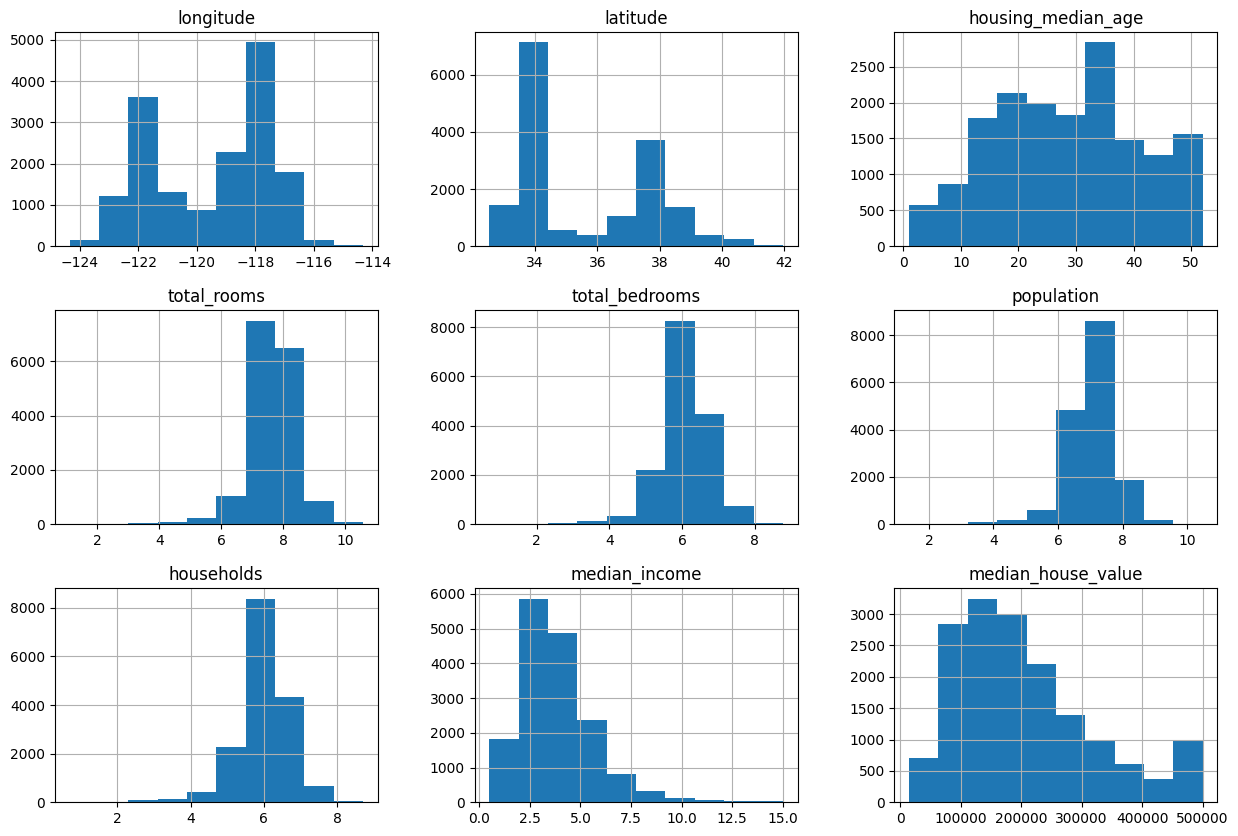

In [125]:
train_data.hist(figsize=(15,10))

### (Features with categorical data)
* e.g. Ocean_proximity is a kind of data that cannot be used directly as it is categorical. We can convert each of the categories into multiple features so that we can better train the model.

In [126]:
train_data.ocean_proximity.value_counts()

,count
ocean_proximity,
<1H OCEAN,7233
INLAND,5207
NEAR OCEAN,2086
NEAR BAY,1816
ISLAND,4


In [127]:
pd.get_dummies(train_data.ocean_proximity)
# pd.get_dummies is used to convert the categorical data into binary(0-1 or True-False), As you can see below one feature is being converted into multiple features.

,<1H OCEAN,INLAND,ISLAND,NEAR BAY,NEAR OCEAN
6918,True,False,False,False,False
12876,False,True,False,False,False
8101,False,False,False,False,True
5153,True,False,False,False,False
19051,False,True,False,False,False
...,...,...,...,...,...
771,False,False,False,True,False
14995,False,False,False,False,True
19103,True,False,False,False,False
6062,True,False,False,False,False


In [128]:
# you can add this data into the train_data df using join.
train_data = train_data.join(pd.get_dummies(train_data.ocean_proximity))

In [129]:
train_data

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity,median_house_value,<1H OCEAN,INLAND,ISLAND,NEAR BAY,NEAR OCEAN
6918,-118.00,33.96,37.0,7.789455,5.780744,6.778785,5.723585,9.1541,<1H OCEAN,453800.0,True,False,False,False,False
12876,-121.36,38.66,22.0,7.965198,6.396930,7.217443,6.295266,2.7955,INLAND,96500.0,False,True,False,False,False
8101,-118.21,33.80,41.0,7.132498,5.634790,6.960348,5.631212,3.2778,NEAR OCEAN,150800.0,False,False,False,False,True
5153,-118.26,33.95,44.0,7.322510,5.913503,6.993015,5.843544,1.2969,<1H OCEAN,94400.0,True,False,False,False,False
19051,-121.81,38.43,30.0,7.423568,5.697093,6.629363,5.680173,3.9286,INLAND,133100.0,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
771,-122.11,37.66,29.0,7.841886,6.467699,7.754910,6.403574,3.2091,NEAR BAY,150000.0,False,False,False,True,False
14995,-117.04,32.73,36.0,7.642524,5.993961,7.001246,5.988961,3.2717,NEAR OCEAN,130700.0,False,False,False,False,True
19103,-122.57,38.27,7.0,8.780941,6.936343,7.973500,6.918695,5.3707,<1H OCEAN,250500.0,True,False,False,False,False
6062,-117.84,34.00,26.0,6.682109,4.770685,5.950643,4.744932,6.8758,<1H OCEAN,253800.0,True,False,False,False,False


In [130]:
# now ocean_proximity is no longer needed, drop it
train_data.drop(["ocean_proximity"], axis=1, inplace=True)
train_data

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,<1H OCEAN,INLAND,ISLAND,NEAR BAY,NEAR OCEAN
6918,-118.00,33.96,37.0,7.789455,5.780744,6.778785,5.723585,9.1541,453800.0,True,False,False,False,False
12876,-121.36,38.66,22.0,7.965198,6.396930,7.217443,6.295266,2.7955,96500.0,False,True,False,False,False
8101,-118.21,33.80,41.0,7.132498,5.634790,6.960348,5.631212,3.2778,150800.0,False,False,False,False,True
5153,-118.26,33.95,44.0,7.322510,5.913503,6.993015,5.843544,1.2969,94400.0,True,False,False,False,False
19051,-121.81,38.43,30.0,7.423568,5.697093,6.629363,5.680173,3.9286,133100.0,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
771,-122.11,37.66,29.0,7.841886,6.467699,7.754910,6.403574,3.2091,150000.0,False,False,False,True,False
14995,-117.04,32.73,36.0,7.642524,5.993961,7.001246,5.988961,3.2717,130700.0,False,False,False,False,True
19103,-122.57,38.27,7.0,8.780941,6.936343,7.973500,6.918695,5.3707,250500.0,True,False,False,False,False
6062,-117.84,34.00,26.0,6.682109,4.770685,5.950643,4.744932,6.8758,253800.0,True,False,False,False,False


<Axes: >

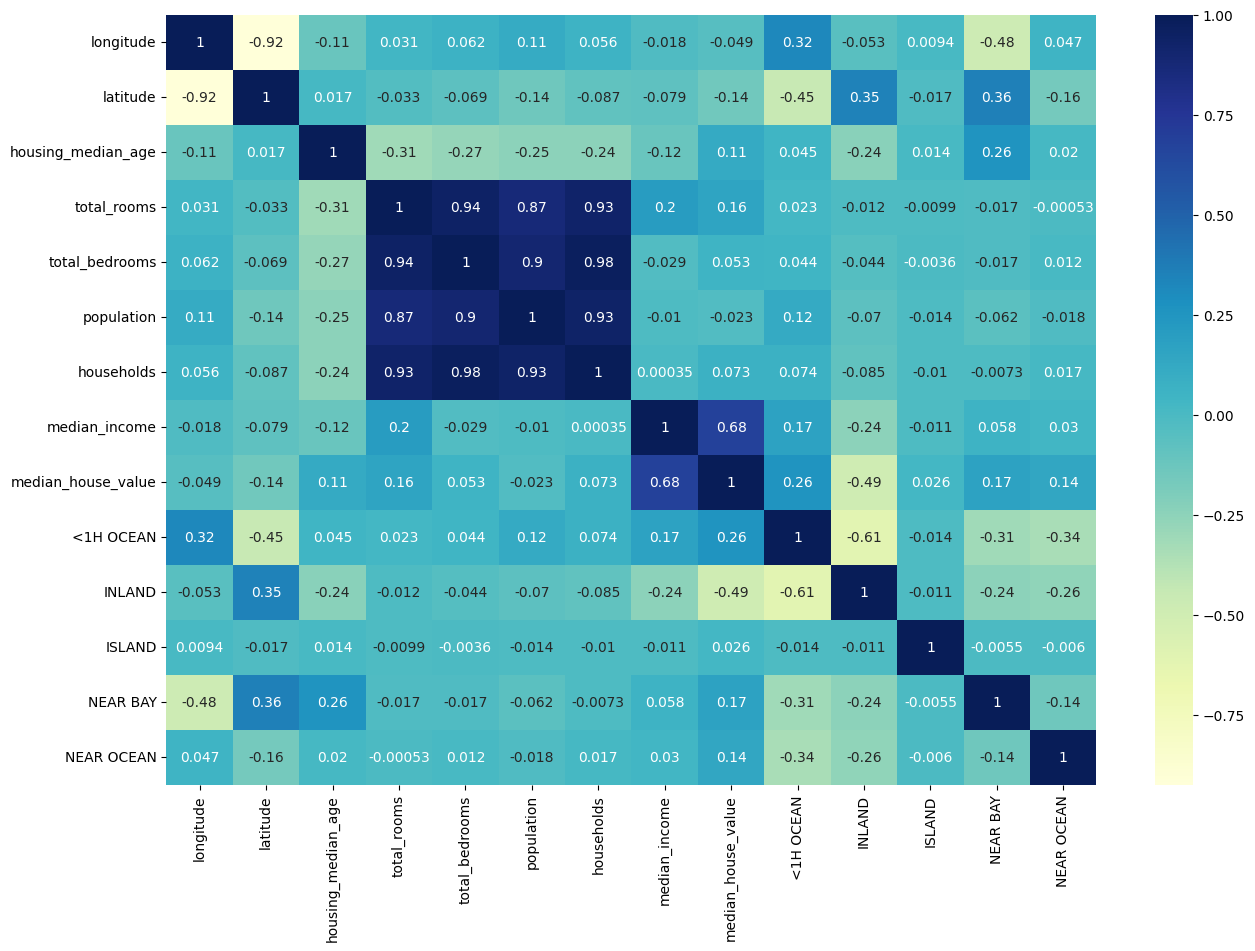

In [131]:
plt.figure(figsize=(15,10))
sns.heatmap(train_data.corr(numeric_only=True), annot=True, cmap="YlGnBu")

<Axes: xlabel='latitude', ylabel='longitude'>

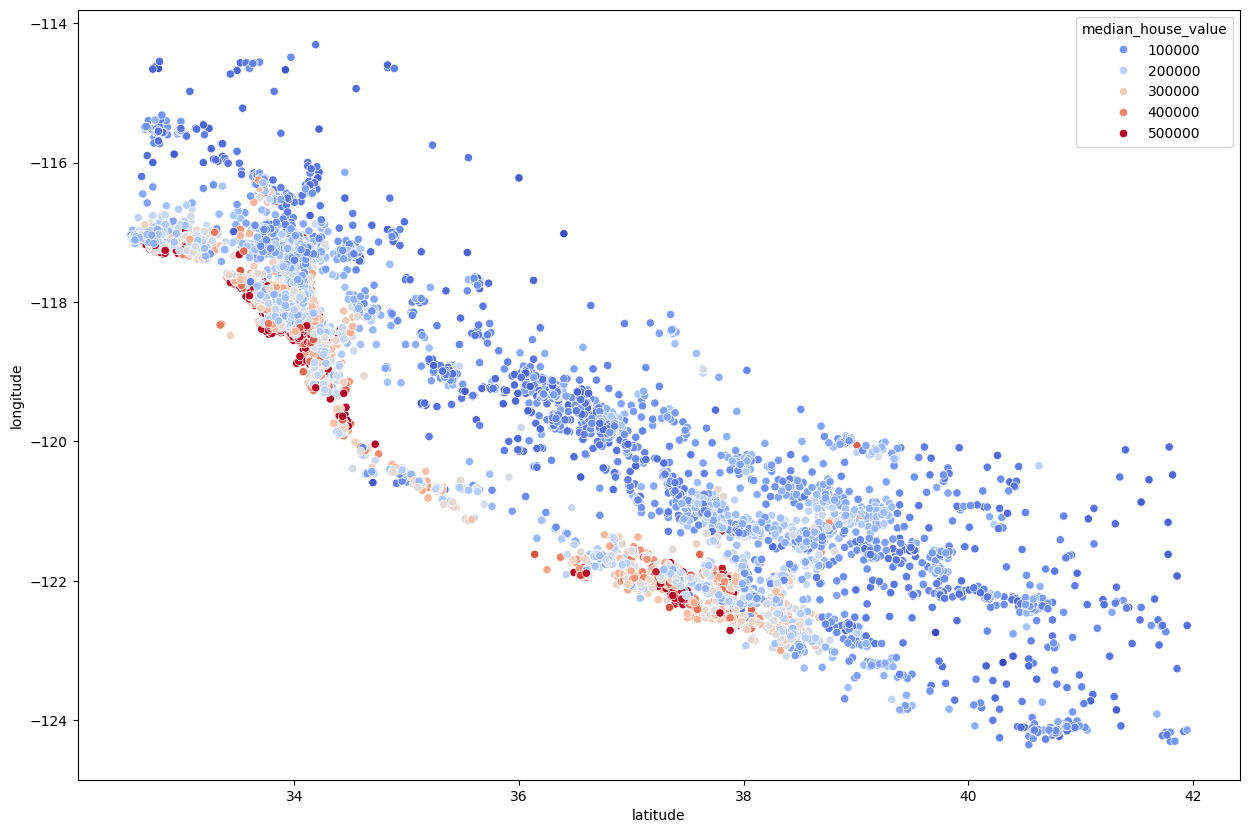

In [132]:
# An interesting vizualization if you have map data(latitude & longitude), hue is what the dot represents in the below example it is the price of house
plt.figure(figsize=(15, 10))
sns.scatterplot(x="latitude", y="longitude", data=train_data, hue="median_house_value", palette="coolwarm")

# Feature Engineering

In [133]:
train_data['bedroom_ratio'] = train_data['total_bedrooms'] / train_data['total_rooms']
train_data['house_rooms'] = train_data['total_rooms'] / train_data['households']

<Axes: >

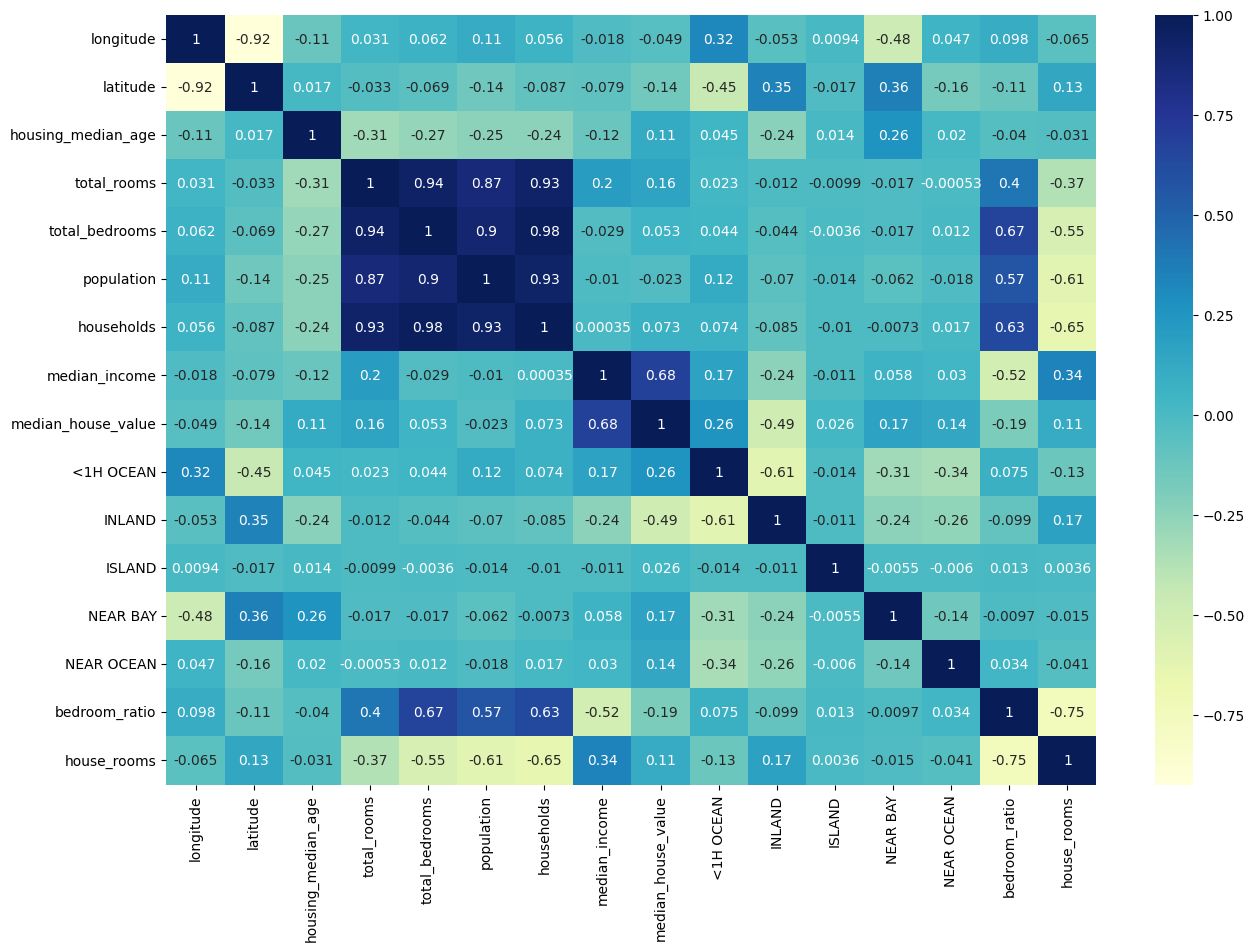

In [134]:
plt.figure(figsize=(15,10))
sns.heatmap(train_data.corr(numeric_only=True), annot=True, cmap="YlGnBu")

# Linear Regression Model

In [135]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x_train, y_train = train_data.drop(['median_house_value'], axis=1), train_data['median_house_value']

reg = LinearRegression()

reg.fit(x_train, y_train)

LinearRegression()

# The x_train and y_train data has already been modified, but it is not done for the test data, so below we are doing it now and then use the test data to check for score


In [136]:
test_data = x_test.join(y_test)

test_data['total_rooms'] = np.log(test_data['total_rooms'] + 1)
test_data['total_bedrooms'] = np.log(test_data['total_bedrooms'] + 1)
test_data['population'] = np.log(test_data['population'] + 1)
test_data['households'] = np.log(test_data['households'] + 1)

test_data = test_data.join(pd.get_dummies(test_data.ocean_proximity))
test_data.drop(["ocean_proximity"], axis=1, inplace=True)

test_data['bedroom_ratio'] = test_data['total_bedrooms'] / test_data['total_rooms']
test_data['house_rooms'] = test_data['total_rooms'] / test_data['households']

In [137]:
x_test, y_test = test_data.drop(['median_house_value'], axis=1), test_data['median_house_value']

In [141]:
reg.score(x_test, y_test)

0.6788927736834687

## Now scale the data and test the score again

In [145]:
x_train_s = scaler.fit_transform(x_train)

x_test_s = scaler.transform(x_test)

reg.fit(x_train_s, y_train)
reg.score(x_test_s, y_test)

0.6788927736834685

# Random Forest Model

In [146]:
from sklearn.ensemble import RandomForestRegressor

forest = RandomForestRegressor()

forest.fit(x_train_s, y_train)

RandomForestRegressor()

In [147]:
forest.score(x_test_s, y_test)

0.816913204534244

* Using Cross Validation to get better scoring values

In [148]:
from sklearn.model_selection import GridSearchCV

forest = RandomForestRegressor()

param_grid = {
    "n_estimators": [100, 200, 300],
    "min_samples_split": [2, 4],
    "max_depth": [None, 4, 8]
}

grid_search = GridSearchCV(forest, param_grid, cv=5,
                          scoring="neg_mean_squared_error",
                          return_train_score=True)
grid_search.fit(x_train_s, y_train)

GridSearchCV(cv=5, estimator=RandomForestRegressor(),
             param_grid={'max_depth': [None, 4, 8], 'min_samples_split': [4],
                         'n_estimators': [200]},
             return_train_score=True, scoring='neg_mean_squared_error')

In [149]:
grid_search.best_estimator_

RandomForestRegressor(min_samples_split=4, n_estimators=200)

In [150]:
grid_search.best_estimator_.score(x_test_s, y_test)

0.8179426045666292